# Analisis de Datos PROYECTO AURELION

## Realizo importacion de librerias y creacion de Path

### Importacion Librerias

In [4]:
!pip install category_encoders


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
import category_encoders as ce

### Creacion Rutas de files

In [6]:
xlsx_path = "/Users/dieh.penalba/Workspace/Peñalba Diego - Proyecto Aurelion/Base de datos/"
clientesFileName = "clientes.xlsx"
productosFileName = "productos.xlsx"
ventasFileName = "ventas.xlsx"
detalleVentasFileName = "detalle_ventas.xlsx"


## Funciones para analisis

### Creacion Funciones para muestra de resultados

In [7]:
def clasificar_moda(numero_de_modas):
    if numero_de_modas == 1:
        return "Unimodal"
    elif numero_de_modas == 2:
        return "Bimodal"
    elif numero_de_modas > 2:
        return "Multimodal"
    else:
        return "Sin Moda"


def clasificar_simetria(media, mediana, moda):
    if mediana < media:
        return "Asimétrica Positiva"
    elif media == mediana == moda:
        return "Simétrica"
    elif mediana > media:
        return "Asimétrica Negativa"


def clasificar_curtosis(curtosis):
    if curtosis > 3:
        return "Leptocúrtica"
    elif curtosis == 3:
        return "Mesocúrtica"
    elif curtosis < 3:
        return "Platicúrtica"

## Analisis tabla por tabla

### Tabla Clientes

#### Creacion y analisis expiatorio del DataFrame

In [8]:
clientes_df = pd.read_excel(xlsx_path+clientesFileName)
clientes_df.head()

,id_cliente,nombre_cliente,email,ciudad,fecha_alta
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2023-01-01
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,2023-01-02
2,3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,2023-01-03
3,4,Uma Martinez,uma.martinez@mail.com,Carlos Paz,2023-01-04
4,5,Agustina Flores,agustina.flores@mail.com,Cordoba,2023-01-05


In [9]:
clientes_df.tail()

,id_cliente,nombre_cliente,email,ciudad,fecha_alta
95,96,Rocio Gonzalez,rocio.gonzalez@mail.com,Cordoba,2023-04-06
96,97,Uma Alvarez,uma.alvarez@mail.com,Cordoba,2023-04-07
97,98,Camila Castro,camila.castro@mail.com,Cordoba,2023-04-08
98,99,Bruno Molina,bruno.molina@mail.com,Villa Maria,2023-04-09
99,100,Agustina Lopez,agustina.lopez@mail.com,Cordoba,2023-04-10


In [10]:
clientes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_cliente      100 non-null    int64         
 1   nombre_cliente  100 non-null    object        
 2   email           100 non-null    object        
 3   ciudad          100 non-null    object        
 4   fecha_alta      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.0+ KB


#### Normalizacion

In [11]:
# Creamos una copia con las transformaciones
clientes_df_norm = clientes_df.rename(columns={
    'id_cliente': 'id',
    'nombre_cliente': 'cliente',
    'fecha_alta': 'alta'
})

# Convertimos la fecha de formato aaaa-mm-dd → dd-mm-aaaa
clientes_df_norm['alta'] = pd.to_datetime(clientes_df_norm['alta']).dt.strftime('%d-%m-%Y')


In [12]:
clientes_df_norm.head()

,id,cliente,email,ciudad,alta
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,01-01-2023
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,02-01-2023
2,3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,03-01-2023
3,4,Uma Martinez,uma.martinez@mail.com,Carlos Paz,04-01-2023
4,5,Agustina Flores,agustina.flores@mail.com,Cordoba,05-01-2023


In [13]:
# me fijo si hay nulos (se que no, pero bueno)
clientes_df_norm.isnull().values.any()

False

In [14]:
clientes_df_norm.describe(include= 'all')

,id,cliente,email,ciudad,alta
count,100.000000,100,100,100,100
unique,NaN,95,100,6,100
top,NaN,Olivia Perez,mariana.lopez@mail.com,Rio Cuarto,01-01-2023
freq,NaN,2,1,23,1
mean,50.500000,NaN,NaN,NaN,NaN
std,29.011492,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,25.750000,NaN,NaN,NaN,NaN
50%,50.500000,NaN,NaN,NaN,NaN
75%,75.250000,NaN,NaN,NaN,NaN


#### Analisis estadistico Analitico

**Creacion variables a mostrar**

In [15]:
#creo variable para que sea mas facil

id_clientes = clientes_df_norm['id']
ciudad_clientes = clientes_df_norm['ciudad']

# veo cantidad de registros
registros_clientes = id_clientes.value_counts()
# veo cantidad de ciudades distintas
ciudades_unicas_clientes = ciudad_clientes.nunique()
# veo cantidad de clientes por ciudad
ciudades_clientes = ciudad_clientes.value_counts()
# veo ciudad mas frecuente
moda_ciudad_clientes = ciudad_clientes.mode().iloc[0]
# Cantidad de modas
cantidad_modas_ciudad = len(ciudad_clientes.mode())
# veo si hay clientes duplicados
duplicados_clientes = clientes_df_norm.duplicated().sum()
# veo si hay mails duplicados
mails_duplicados_clientes = clientes_df_norm['email'].duplicated().sum()


#### Muestra datos encontrados

In [16]:
def muestra_resultados_analisis_clientes():
    print("============================================")
    print("ANÁLISIS DE TABLA CLIENTES")
    print("============================================")

    print("\nCantidad de registros:", registros_clientes)
    print("\nCantidad de ciudades distintas:", ciudades_unicas_clientes)
    print("\nCiudad más frecuente:", moda_ciudad_clientes)

    print("\nDistribución de ciudades:")
    print(ciudades_clientes)

    print("\nCantidad de modas:")
    print(cantidad_modas_ciudad)
    print(f"Clasificacion: {clasificar_moda(cantidad_modas_ciudad)}")

    print("\nClientes duplicados por nombre:")
    print(duplicados_clientes)
    print("\nClientes duplicados por mail:")
    print(duplicados_clientes)

    print("""
        Interpretación:
        Los clientes se encuentras concentrados en pocas ciudades,
        La ciudad mas frecuente es Rio Cuarto,
        pero la diferencia cantidad de clientes no es tan significativa.
    """)
    print("============================================")

muestra_resultados_analisis_clientes()

ANÁLISIS DE TABLA CLIENTES

Cantidad de registros: id
1      1
64     1
74     1
73     1
72     1
      ..
31     1
30     1
29     1
28     1
100    1
Name: count, Length: 100, dtype: int64

Cantidad de ciudades distintas: 6

Ciudad más frecuente: Rio Cuarto

Distribución de ciudades:
ciudad
Rio Cuarto     23
Alta Gracia    21
Carlos Paz     15
Villa Maria    15
Cordoba        13
Mendiolaza     13
Name: count, dtype: int64

Cantidad de modas:
1
Clasificacion: Unimodal

Clientes duplicados por nombre:
0

Clientes duplicados por mail:
0

        Interpretación:
        Los clientes se encuentras concentrados en pocas ciudades,
        La ciudad mas frecuente es Rio Cuarto,
        pero la diferencia cantidad de clientes no es tan significativa.
    


### Tabla Productos

#### Creacion y analisis expiatorio del DataFrame

In [53]:
productos_df = pd.read_excel(xlsx_path+productosFileName)
productos_df.head(10)

,id_producto,nombre_producto,categoria,precio_unitario
0,1,Coca Cola 1.5L,Alimentos,2347
1,2,Pepsi 1.5L,Limpieza,4973
2,3,Sprite 1.5L,Alimentos,4964
3,4,Fanta Naranja 1.5L,Limpieza,2033
4,5,Agua Mineral 500ml,Alimentos,4777
5,6,Jugo de Naranja 1L,Limpieza,4170
6,7,Jugo de Manzana 1L,Alimentos,3269
7,8,Energética Nitro 500ml,Limpieza,4218
8,9,Yerba Mate Suave 1kg,Alimentos,3878
9,10,Yerba Mate Intensa 1kg,Limpieza,4883


In [55]:
productos_df.tail(20)

,id_producto,nombre_producto,categoria,precio_unitario
80,81,Aceitunas Verdes 200g,Alimentos,2520
81,82,Aceitunas Negras 200g,Limpieza,2394
82,83,Queso Untable 190g,Alimentos,1830
83,84,Queso Azul 150g,Limpieza,1645
84,85,Jugo en Polvo Naranja,Alimentos,1856
85,86,Jugo en Polvo Limón,Limpieza,4090
86,87,Sopa Instantánea Pollo,Alimentos,1679
87,88,Caldo Concentrado Carne,Limpieza,2570
88,89,Caldo Concentrado Verdura,Alimentos,1003
89,90,Toallas Húmedas x50,Limpieza,2902


In [18]:
productos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_producto      100 non-null    int64 
 1   nombre_producto  100 non-null    object
 2   categoria        100 non-null    object
 3   precio_unitario  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB


#### Normalizacion

In [19]:
# Creamos una nueva tabla con los nombres normalizados
productos_df_norm = productos_df.rename(columns={
    'id_producto': 'id',
    'nombre_producto': 'producto',
    'categoria': 'categoria',
    'precio_unitario': 'precio'
})

# Convertimos la columna de precio a tipo float
productos_df_norm['precio'] = productos_df_norm['precio'].astype(float)
productos_df_norm.head()

,id,producto,categoria,precio
0,1,Coca Cola 1.5L,Alimentos,2347.0
1,2,Pepsi 1.5L,Limpieza,4973.0
2,3,Sprite 1.5L,Alimentos,4964.0
3,4,Fanta Naranja 1.5L,Limpieza,2033.0
4,5,Agua Mineral 500ml,Alimentos,4777.0


In [20]:
# me fijo si hay nulos (se que no, pero bueno)
productos_df_norm.isnull().values.any()

False

In [21]:
productos_df_norm.describe(include= 'all')

,id,producto,categoria,precio
count,100.000000,100,100,100.000000
unique,NaN,100,2,NaN
top,NaN,Coca Cola 1.5L,Alimentos,NaN
freq,NaN,1,50,NaN
mean,50.500000,NaN,NaN,2718.550000
std,29.011492,NaN,NaN,1381.635324
min,1.000000,NaN,NaN,272.000000
25%,25.750000,NaN,NaN,1590.000000
50%,50.500000,NaN,NaN,2516.000000
75%,75.250000,NaN,NaN,4026.500000


#### Analisis estadistico Analitico

**Creacion variables a mostrar**

In [22]:
# creo variable para que sea mas facil
categorias_productos = productos_df_norm['categoria']
precio_productos = productos_df_norm['precio']

#veo cantidad de registros
registros_productos = len(productos_df_norm)
# veo cantidad de categorias distintas
cantidad_categorias_productos = categorias_productos.nunique()
# cuento frecuencia de cada categoria
categoria_frecuencias_productos = categorias_productos.value_counts()
# veo el producto mas barato y mas caro
id_producto_min = productos_df_norm.loc[productos_df_norm['precio'].idxmin()]
precio_minimo_producto = precio_productos.min()
id_producto_max = productos_df_norm.loc[productos_df_norm['precio'].idxmax()]
precio_maximo_producto = precio_productos.max()
rango_productos = precio_maximo_producto - precio_minimo_producto
# Calculo medidas estadisticas basicas (Medidas de centralizacion)
media_productos = precio_productos.mean()
mediana_productos = precio_productos.median()
moda_productos = precio_productos.mode().head().tolist()
desvio_estandard_productos = precio_productos.std
kurtosis_productos = precio_productos.kurtosis()
asimetria_productos = precio_productos.skew()
# Analizo cuartiles y outliers (Medidas de dispersion)
quantiles_productos = precio_productos.quantile([0.25, 0.50, 0.75])
quantiles_productos = quantiles_productos.rename(index={0.25 : '25%', 0.50: '50% (mediana)', 0.75: '75%'})
q1_productos = quantiles_productos.loc['25%']
q3_productos = quantiles_productos.loc['75%']
iqr_productos = q3_productos - q1_productos
lim_inferior_productos = q1_productos - 1.5 * iqr_productos
lim_superior_productos = q3_productos + 1.5 * iqr_productos
outliers_productos = precio_productos[(precio_productos < lim_inferior_productos) | (precio_productos > lim_superior_productos)]
concentracion_Q1_Q2_productos = ((precio_productos >= q1_productos) & (precio_productos <= mediana_productos)).sum() / len(precio_productos) * 100
concentracion_Q2_Q3_productos = ((precio_productos >= mediana_productos) & (precio_productos <= q3_productos)).sum() / len(precio_productos) * 100
concentracion_Q1_Q3_productos = ((precio_productos >= q1_productos) & (precio_productos <= q3_productos)).sum() / len(precio_productos) * 100


#### Muestra datos

In [23]:
def muestra_resultados_producto():
    print("============================================")
    print("ANÁLISIS DE TABLA PRODUCTOS")
    print("============================================")

    print("\nCantidad de registros:", registros_productos)
    print("\nCantidad de categorías:", cantidad_categorias_productos)
    print("\nCategorías y frecuencia:", categoria_frecuencias_productos)

    print("\n============================================")
    print("ESTADÍSTICAS BÁSICAS PRECIO")
    print("============================================")

    print("\nProducto valor minimo:", id_producto_min)

    print("\nProducto valor máximo:", id_producto_max)

    print("\nRango (máx - mín):", rango_productos)


    print("\nMedia:", round(media_productos, 2))
    print("Mediana:", mediana_productos)
    print("Moda:", moda_productos)
    print("Cantidad de modas:", len(moda_productos))
    print("clasificacion de moda:", clasificar_moda(len(moda_productos)))
    print("Curtosis:", round(kurtosis_productos, 2))
    print("Clasificación de curtosis:", clasificar_curtosis(kurtosis_productos))
    print("Asimetría:", round(asimetria_productos, 2))
    print("Clasificación de asimetría:", clasificar_simetria(media_productos, mediana_productos, moda_productos[0]))

    print("\nCuartiles:")
    print(quantiles_productos)

    print(f"\nCantidad de outliers: {len(outliers_productos)}")

    if (q3_productos - mediana_productos) > (mediana_productos - q1_productos):
        print("\nDistribución sesgada hacia la derecha (asimetría positiva).")
    elif (q3_productos - mediana_productos) < (mediana_productos - q1_productos):
        print("\nDistribución sesgada hacia la izquierda (asimetría negativa).")
    else:
        print("\nDistribución aproximadamente simétrica.")
        
    print(f"\nConcentracion de quantiles")
    print(f"Concentracion Q1-Q2: {concentracion_Q1_Q2_productos:.2f}%")
    print(f"Concentracion Q2-Q3: {concentracion_Q2_Q3_productos:.2f}%")
    print(f"Concentracion Q1-Q3: {concentracion_Q1_Q3_productos:.2f}%")


    print("""
        Interpretación:
        2 categorías equilibradas, rango amplio de precios, leve sesgo a la derecha.
    """)

    print("============================================")

muestra_resultados_producto()

ANÁLISIS DE TABLA PRODUCTOS

Cantidad de registros: 100

Cantidad de categorías: 2

Categorías y frecuencia: categoria
Alimentos    50
Limpieza     50
Name: count, dtype: int64

ESTADÍSTICAS BÁSICAS PRECIO

Producto valor minimo: id                            21
producto     Pan Lactal Integral
categoria              Alimentos
precio                     272.0
Name: 20, dtype: object

Producto valor máximo: id                       61
producto     Miel Pura 250g
categoria         Alimentos
precio               4982.0
Name: 60, dtype: object

Rango (máx - mín): 4710.0

Media: 2718.55
Mediana: 2516.0
Moda: [2512.0]
Cantidad de modas: 1
clasificacion de moda: Unimodal
Curtosis: -1.17
Clasificación de curtosis: Platicúrtica
Asimetría: 0.15
Clasificación de asimetría: Asimétrica Positiva

Cuartiles:
25%              1590.0
50% (mediana)    2516.0
75%              4026.5
Name: precio, dtype: float64

Cantidad de outliers: 0

Distribución sesgada hacia la derecha (asimetría positiva).

Concent

### Tabla Ventas

#### Creacion y analisis expiatorio del DataFrame

In [24]:
ventas_df = pd.read_excel(xlsx_path+ventasFileName)
ventas_df.head()

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr
2,3,2024-01-13,20,Tomas Acosta,tomas.acosta@mail.com,tarjeta
3,4,2024-02-27,36,Martina Molina,martina.molina@mail.com,transferencia
4,5,2024-06-11,56,Bruno Diaz,bruno.diaz@mail.com,tarjeta


In [25]:
ventas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venta        120 non-null    int64         
 1   fecha           120 non-null    datetime64[ns]
 2   id_cliente      120 non-null    int64         
 3   nombre_cliente  120 non-null    object        
 4   email           120 non-null    object        
 5   medio_pago      120 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 5.8+ KB


#### Normalizacion

In [26]:
# Creamos una nueva tabla con los nombres normalizados
ventas_df_norm = ventas_df.rename(columns={'id_venta': 'id'})

# Formatear la fecha a dd-mm-aaaa
ventas_df_norm['fecha'] = pd.to_datetime(ventas_df_norm['fecha']).dt.strftime('%d-%m-%Y')

# Eliminar columnas innecesarias (nombre y email del cliente)
ventas_df_norm = ventas_df_norm.drop(columns=['nombre_cliente', 'email'])

In [27]:
ventas_df_norm.head()


,id,fecha,id_cliente,medio_pago
0,1,19-06-2024,62,tarjeta
1,2,17-03-2024,49,qr
2,3,13-01-2024,20,tarjeta
3,4,27-02-2024,36,transferencia
4,5,11-06-2024,56,tarjeta


In [28]:
# me fijo si hay nulos (se que no, pero bueno)
ventas_df_norm.isnull().values.any()

False

#### Encodeo Medios de pago. 


In [29]:
# me fijos los valores unicos
ventas_df_norm['medio_pago'].value_counts()




medio_pago
efectivo         37
qr               30
transferencia    27
tarjeta          26
Name: count, dtype: int64

In [30]:
# Crear las columnas One-Hot
medio_pago_encoded = pd.get_dummies(ventas_df_norm['medio_pago'], prefix='medio_pago')

# Combinar con el DataFrame original y eliminar la columna original
ventas_df_encoded = pd.concat([ventas_df_norm.drop('medio_pago', axis=1), medio_pago_encoded], axis=1)# conviene dropear para no generar ppodibles duplicados

ventas_df_encoded.head()

,id,fecha,id_cliente,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia
0,1,19-06-2024,62,False,False,True,False
1,2,17-03-2024,49,False,True,False,False
2,3,13-01-2024,20,False,False,True,False
3,4,27-02-2024,36,False,False,False,True
4,5,11-06-2024,56,False,False,True,False


In [31]:
ventas_df_norm.describe(include= 'all')

,id,fecha,id_cliente,medio_pago
count,120.000000,120,120.000000,120
unique,NaN,93,NaN,4
top,NaN,19-06-2024,NaN,efectivo
freq,NaN,3,NaN,37
mean,60.500000,NaN,47.291667,NaN
std,34.785054,NaN,27.854181,NaN
min,1.000000,NaN,1.000000,NaN
25%,30.750000,NaN,24.500000,NaN
50%,60.500000,NaN,48.500000,NaN
75%,90.250000,NaN,67.500000,NaN


#### Analisis estadistico Analitico

**Creacion y muestra de resultados**

In [32]:
def muestra_resultados_ventas():
    print("============================================")
    print("ANÁLISIS DE TABLA VENTAS")
    print("============================================")

    registros_ventas = len(ventas_df_norm)
    print("\nCantidad de registros:", registros_ventas)

    print("\n============================================")
    print("ESTADÍSTICAS ID_CLIENTE (variable discreta)")
    print("============================================")
    ventas_id_clientes = ventas_df_norm['id_cliente']
    compras_id_clientes = ventas_id_clientes.value_counts()
    cant_ventas_clientes_unicos = ventas_id_clientes.nunique()

    print('\nAnálisis de frecuencia de compra por cliente:')
    print("Cantidad de clientes distintos:", cant_ventas_clientes_unicos)
    media_compras_por_clientes = compras_id_clientes.mean()
    print("Media de compras por cliente:", round(media_compras_por_clientes, 2))
    mediana_compras_por_clientes = compras_id_clientes.median()
    print("Mediana de compras por cliente:", mediana_compras_por_clientes)
    maximo_compras_por_cliente = compras_id_clientes.max()
    print("Máximo de compras:", maximo_compras_por_cliente)
    minimo_compras_por_cliente = compras_id_clientes.min()
    print("Mínimo de compras:", minimo_compras_por_cliente)

    print('\nAnálisis de estadisticas basicas ID_cliente:')
    print("Valor mínimo:", ventas_id_clientes.min())
    print("Valor máximo:", ventas_id_clientes.max())
    print("Rango:", ventas_id_clientes.max() - ventas_id_clientes.min())
    print("Media:", round(ventas_id_clientes.mean(), 2))
    print("Mediana:", ventas_id_clientes.median())
    print("Moda:", ventas_id_clientes.mode().head().tolist())
    print("\nCuartiles:")
    print(ventas_id_clientes.quantile([0.25, 0.5, 0.75]))

    print("""
    Interpretación:
        1,79 compras promedio por cliente, 
        Mayoría de clientes ocasionales, minoría recurrente fiel
    """)
    print("============================================")

muestra_resultados_ventas()

ANÁLISIS DE TABLA VENTAS

Cantidad de registros: 120

ESTADÍSTICAS ID_CLIENTE (variable discreta)

Análisis de frecuencia de compra por cliente:
Cantidad de clientes distintos: 67
Media de compras por cliente: 1.79
Mediana de compras por cliente: 2.0
Máximo de compras: 5
Mínimo de compras: 1

Análisis de estadisticas basicas ID_cliente:
Valor mínimo: 1
Valor máximo: 100
Rango: 99
Media: 47.29
Mediana: 48.5
Moda: [56]

Cuartiles:
0.25    24.5
0.50    48.5
0.75    67.5
Name: id_cliente, dtype: float64

    Interpretación:
        1,79 compras promedio por cliente, 
        Mayoría de clientes ocasionales, minoría recurrente fiel
    


### Tabla detalle ventas

#### Creacion y analisis expiatorio del DataFrame

In [48]:
detalleVentas_df = pd.read_excel(xlsx_path+detalleVentasFileName)
detalleVentas_df.head(10)

,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
0,1,90,Toallas Húmedas x50,1,2902,2902
1,2,82,Aceitunas Negras 200g,5,2394,11970
2,2,39,Helado Vainilla 1L,5,469,2345
3,2,70,Fernet 750ml,2,4061,8122
4,2,22,Medialunas de Manteca,1,2069,2069
5,2,79,Hamburguesas Congeladas x4,4,2420,9680
6,3,9,Yerba Mate Suave 1kg,2,3878,7756
7,3,2,Pepsi 1.5L,2,4973,9946
8,3,85,Jugo en Polvo Naranja,1,1856,1856
9,4,4,Fanta Naranja 1.5L,2,2033,4066


In [34]:
detalleVentas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_venta         343 non-null    int64 
 1   id_producto      343 non-null    int64 
 2   nombre_producto  343 non-null    object
 3   cantidad         343 non-null    int64 
 4   precio_unitario  343 non-null    int64 
 5   importe          343 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 16.2+ KB


In [46]:
detalleVentas_df.describe(include= 'all')

,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
count,343.000000,343.000000,343,343.000000,343.000000,343.000000
unique,NaN,NaN,95,NaN,NaN,NaN
top,NaN,NaN,Queso Rallado 150g,NaN,NaN,NaN
freq,NaN,NaN,9,NaN,NaN,NaN
mean,61.492711,49.139942,NaN,2.962099,2654.495627,7730.078717
std,34.835525,29.135461,NaN,1.366375,1308.694720,5265.543077
min,1.000000,1.000000,NaN,1.000000,272.000000,272.000000
25%,31.000000,23.000000,NaN,2.000000,1618.500000,3489.000000
50%,61.000000,47.000000,NaN,3.000000,2512.000000,6702.000000
75%,93.000000,76.000000,NaN,4.000000,3876.000000,10231.500000


#### Normalizacion

In [35]:
ventas_detalle_df_norm = detalleVentas_df.rename(
    columns={
        'id_venta': 'ID_venta',
        'id_producto': 'FK_producto'
    }
)

# Eliminar columna 'nombre_producto'
ventas_detalle_df_norm = ventas_detalle_df_norm.drop(columns=['nombre_producto'])

# Convertir a float las columnas precio e importe
ventas_detalle_df_norm[['precio_unitario', 'importe']] = ventas_detalle_df_norm[['precio_unitario', 'importe']].astype(float)

ventas_detalle_df_norm.head()


,ID_venta,FK_producto,cantidad,precio_unitario,importe
0,1,90,1,2902.0,2902.0
1,2,82,5,2394.0,11970.0
2,2,39,5,469.0,2345.0
3,2,70,2,4061.0,8122.0
4,2,22,1,2069.0,2069.0


In [36]:
# me fijo si hay nulos (se que no, pero bueno)
ventas_detalle_df_norm.isnull().values.any()

False

#### Estandarizo los importes para que los algoritmos no se inclinen por las variables mas grandes

In [37]:
# importo las librerias de sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler_standard= StandardScaler() #instancio objeto
importe_std= scaler_standard.fit_transform(ventas_detalle_df_norm[['importe']])

# Agrego la columna estandarizada al df normalizada
ventas_detalle_df_norm['importe_std'] = importe_std

#Veo como quedo
ventas_detalle_df_norm.head()

,ID_venta,FK_producto,cantidad,precio_unitario,importe,importe_std
0,1,90,1,2902.0,2902.0,-0.918259
1,2,82,5,2394.0,11970.0,0.806396
2,2,39,5,469.0,2345.0,-1.024196
3,2,70,2,4061.0,8122.0,0.074540
4,2,22,1,2069.0,2069.0,-1.076688


In [38]:
ventas_detalle_df_norm.describe(include= 'all')

,ID_venta,FK_producto,cantidad,precio_unitario,importe,importe_std
count,343.000000,343.000000,343.000000,343.000000,343.000000,3.430000e+02
mean,61.492711,49.139942,2.962099,2654.495627,7730.078717,2.589441e-17
std,34.835525,29.135461,1.366375,1308.694720,5265.543077,1.001461e+00
min,1.000000,1.000000,1.000000,272.000000,272.000000,-1.418462e+00
25%,31.000000,23.000000,2.000000,1618.500000,3489.000000,-8.066166e-01
50%,61.000000,47.000000,3.000000,2512.000000,6702.000000,-1.955317e-01
75%,93.000000,76.000000,4.000000,3876.000000,10231.500000,4.757488e-01
max,120.000000,100.000000,5.000000,4982.000000,24865.000000,3.258914e+00


#### Analisis estadistico Analitico

**Creacion variables a mostrar**

In [ ]:
# creo variable para que sea mas facil
importe_ventas_detalle = ventas_detalle_df_norm['importe']
precio_ventas_detalle = ventas_detalle_df_norm['precio_unitario']
cantidad_ventas_detalle = ventas_detalle_df_norm['cantidad']

print(ventas_detalle_df_norm[['cantidad', 'precio_unitario', 'importe']].describe())

# Estadisticas de Importe
importe_vd_min = importe_ventas_detalle.min()
importe_vd_max = importe_ventas_detalle.max()
rango_importe_vd = importe_vd_max - importe_vd_min
media_importe_vd = importe_ventas_detalle.mean()
mediana_importe_vd = importe_ventas_detalle.median()
moda_importe_vd = importe_ventas_detalle.mode().head().tolist()
desvio_estandard_importe_vd = importe_ventas_detalle.std
kurtosis_importe_vd = importe_ventas_detalle.kurtosis()
asimetria_importe_vd = importe_ventas_detalle.skew()
# Cuartiles y outliers
quantiles_importe_vd = importe_ventas_detalle.quantile([0.25, 0.50, 0.75])
quantiles_importe_vd = quantiles_importe_vd.rename(index={0.25 : '25%', 0.50: '50% (mediana)', 0.75: '75%'})
q1_importe_vd = quantiles_importe_vd.loc['25%']
q3_importe_vd = quantiles_importe_vd.loc['75%']
iqr_importe_vd = q3_importe_vd - q1_importe_vd
lim_inferior_importe_vd = q1_importe_vd - 1.5 * iqr_importe_vd
lim_superior_importe_vd = q3_importe_vd + 1.5 * iqr_importe_vd
outliers_importe_vd = importe_ventas_detalle[(importe_ventas_detalle < lim_inferior_importe_vd) | (importe_ventas_detalle > lim_superior_importe_vd)]
concentracion_Q1_Q2_importe_vd = ((importe_ventas_detalle >= q1_importe_vd) & (importe_ventas_detalle <= mediana_importe_vd)).sum() / len(importe_ventas_detalle) * 100
concentracion_Q2_Q3_importe_vd = ((importe_ventas_detalle >= mediana_importe_vd) & (importe_ventas_detalle <= q3_importe_vd)).sum() / len(importe_ventas_detalle) * 100
concentracion_Q1_Q3_importe_vd = ((importe_ventas_detalle >= q1_importe_vd) & (importe_ventas_detalle <= q3_importe_vd)).sum() / len(importe_ventas_detalle) * 100


#Estadisticas de Precio Unitario
precio_vd_min = precio_ventas_detalle.min()
precio_vd_max = precio_ventas_detalle.max()
rango_precio_vd = precio_vd_max - precio_vd_min
media_precio_vd = precio_ventas_detalle.mean()
mediana_precio_vd = precio_ventas_detalle.median()
moda_precio_vd = precio_ventas_detalle.mode().head().tolist()
desvio_estandard_precio_vd = precio_ventas_detalle.std
kurtosis_precio_vd = precio_ventas_detalle.kurtosis()
asimetria_precio_vd = precio_ventas_detalle.skew()
#Cuartiles y outliers
quantiles_precio_vd = precio_ventas_detalle.quantile([0.25, 0.50, 0.75])
quantiles_precio_vd = quantiles_precio_vd.rename(index={0.25 : '25%', 0.50: '50% (mediana)', 0.75: '75%'})
q1_precio_vd = quantiles_precio_vd.loc['25%']
q3_precio_vd = quantiles_precio_vd.loc['75%']
iqr_precio_vd = q3_precio_vd - q1_precio_vd
lim_inferior_precio_vd = q1_precio_vd - 1.5 * iqr_precio_vd
lim_superior_precio_vd = q3_precio_vd + 1.5 * iqr_precio_vd
outliers_precio_vd = precio_ventas_detalle[(precio_ventas_detalle < lim_inferior_precio_vd) | (precio_ventas_detalle > lim_superior_precio_vd)]
concentracion_Q1_Q2_precio_vd = ((precio_ventas_detalle >= q1_precio_vd) & (precio_ventas_detalle <= mediana_precio_vd)).sum() / len(precio_ventas_detalle) * 100
concentracion_Q2_Q3_precio_vd = ((precio_ventas_detalle >= mediana_precio_vd) & (precio_ventas_detalle <= q3_precio_vd)).sum() / len(precio_ventas_detalle) * 100
concentracion_Q1_Q3_precio_vd = ((precio_ventas_detalle >= q1_precio_vd) & (precio_ventas_detalle <= q3_precio_vd)).sum() / len(precio_ventas_detalle) * 100


# Estadisticas de Cantidad
cantidad_vd_min = cantidad_ventas_detalle.min()
cantidad_vd_max = cantidad_ventas_detalle.max()
rango_cantidad_vd = cantidad_vd_max - cantidad_vd_min
media_cantidad_vd = cantidad_ventas_detalle.mean()
mediana_cantidad_vd = cantidad_ventas_detalle.median()
moda_cantidad_vd = cantidad_ventas_detalle.mode().head().tolist()
desvio_estandard_precio_vd = precio_ventas_detalle.std
kurtosis_cantidad_vd = precio_ventas_detalle.kurtosis()
asimetria_cantidad_vd = precio_ventas_detalle.skew()
# Cuartiles y outliers
quantiles_cantidad_vd = cantidad_ventas_detalle.quantile([0.25, 0.50, 0.75])
quantiles_cantidad_vd = quantiles_cantidad_vd.rename(index={0.25 : '25%', 0.50: '50% (mediana)', 0.75: '75%'})
q1_cantidad_vd = quantiles_cantidad_vd.loc['25%']
q3_cantidad_vd = quantiles_cantidad_vd.loc['75%']
iqr_cantidad_vd = q3_cantidad_vd - q1_cantidad_vd
lim_inferior_cantidad_vd = q1_cantidad_vd - 1.5 * iqr_cantidad_vd
lim_superior_cantidad_vd = q3_cantidad_vd + 1.5 * iqr_cantidad_vd
outliers_cantidad_vd = cantidad_ventas_detalle[(cantidad_ventas_detalle < lim_inferior_cantidad_vd) | (cantidad_ventas_detalle > lim_superior_cantidad_vd)]
concentracion_Q1_Q2_cantidad_vd = ((cantidad_ventas_detalle >= q1_cantidad_vd) & (cantidad_ventas_detalle <= mediana_cantidad_vd)).sum() / len(cantidad_ventas_detalle) * 100
concentracion_Q2_Q3_cantidad_vd = ((cantidad_ventas_detalle >= mediana_cantidad_vd) & (cantidad_ventas_detalle <= q3_cantidad_vd)).sum() / len(cantidad_ventas_detalle) * 100
concentracion_Q1_Q3_cantidad_vd = ((cantidad_ventas_detalle >= q1_cantidad_vd) & (cantidad_ventas_detalle <= q3_cantidad_vd)).sum() / len(cantidad_ventas_detalle) * 100

         cantidad  precio_unitario       importe
count  343.000000       343.000000    343.000000
mean     2.962099      2654.495627   7730.078717
std      1.366375      1308.694720   5265.543077
min      1.000000       272.000000    272.000000
25%      2.000000      1618.500000   3489.000000
50%      3.000000      2512.000000   6702.000000
75%      4.000000      3876.000000  10231.500000
max      5.000000      4982.000000  24865.000000


#### Muestra resultados obtenidos

In [40]:
def muestra_resultados_detalle_ventas():
    print("============================================")
    print("ANÁLISIS DE TABLA DETALLE VENTA")
    print("============================================")

    print("\nCantidad de registros:", len(ventas_detalle_df_norm))

    print("\n============================================")
    print("ESTADÍSTICAS BÁSICAS IMPORTE")
    print("============================================")

    print("Valor mínimo:", importe_vd_min)
    print("Valor máximo:", importe_vd_max )
    print("Rango (máx - mín):", rango_importe_vd)
    print("Media:", round(media_importe_vd, 2))
    print("Mediana:", mediana_importe_vd)
    print("Moda:",  moda_importe_vd)
    print("Cantidad de modas:", len(moda_importe_vd))
    print("clasificacion de moda:", clasificar_moda(len(moda_importe_vd)))
    print("Curtosis:", round(kurtosis_importe_vd, 2))
    print("Clasificación de curtosis:", clasificar_curtosis(kurtosis_importe_vd))
    print("Asimetría:", round(asimetria_importe_vd, 2))
    print("Clasificación de asimetría:", clasificar_simetria(media_importe_vd, mediana_importe_vd, moda_importe_vd[0]))

    print("Cuartiles:")
    print(quantiles_importe_vd)

    print(f"\nCantidad de outliers: {len(outliers_importe_vd)}")

    if (q3_importe_vd - mediana_importe_vd) > (mediana_importe_vd - q1_importe_vd):
        print("Distribución sesgada hacia la derecha (asimetría positiva).")
    elif (q3_importe_vd - mediana_importe_vd) < (mediana_importe_vd - q1_importe_vd):
        print("Distribución sesgada hacia la izquierda (asimetría negativa).")
    else:
        print("Distribución aproximadamente simétrica.")

    print(f"\nConcentracion de quantiles")
    print(f"Concentracion Q1-Q2: {concentracion_Q1_Q2_importe_vd:.2f}%")
    print(f"Concentracion Q2-Q3: {concentracion_Q2_Q3_importe_vd:.2f}%")
    print(f"Concentracion Q1-Q3: {concentracion_Q1_Q3_importe_vd:.2f}%")

    print("\n============================================")
    print("ESTADÍSTICAS BÁSICAS PRECIO UNITARIO")
    print("============================================")

    print("Valor mínimo:", precio_vd_min)
    print("Valor máximo:", precio_vd_max )
    print("Rango (máx - mín):", rango_precio_vd)
    print("Media:", round(media_precio_vd, 2))
    print("Mediana:", mediana_precio_vd)
    print("Moda:",  moda_precio_vd)
    print("Cantidad de modas:", len(moda_precio_vd))
    print("clasificacion de moda:", clasificar_moda(len(moda_precio_vd)))
    print("Curtosis:", round(kurtosis_precio_vd, 2))
    print("Clasificación de curtosis:", clasificar_curtosis(kurtosis_precio_vd))
    print("Asimetría:", round(asimetria_precio_vd, 2))
    print("Clasificación de asimetría:", clasificar_simetria(media_precio_vd, mediana_precio_vd, moda_precio_vd[0]))

    print(f"\nCantidad de outliers: {len(outliers_precio_vd)}")

    print("\nCuartiles:")
    print(quantiles_precio_vd)

    if (q3_precio_vd - mediana_precio_vd) > (mediana_precio_vd - q1_precio_vd):
        print("Distribución sesgada hacia la derecha (asimetría positiva).")
    elif (q3_precio_vd - mediana_precio_vd) < (mediana_precio_vd - q1_precio_vd):
        print("Distribución sesgada hacia la izquierda (asimetría negativa).")
    else:
        print("Distribución aproximadamente simétrica.")

    print(f"\nConcentracion de quantiles")
    print(f"Concentracion Q1-Q2: {concentracion_Q1_Q2_precio_vd:.2f}%")
    print(f"Concentracion Q2-Q3: {concentracion_Q2_Q3_precio_vd:.2f}%")
    print(f"Concentracion Q1-Q3: {concentracion_Q1_Q3_precio_vd:.2f}%")

    print("\n============================================")
    print("ESTADÍSTICAS BÁSICAS CANTIDAD")
    print("============================================")

    print("Valor mínimo:", cantidad_vd_min)
    print("Valor máximo:", cantidad_vd_max )
    print("Rango (máx - mín):", rango_cantidad_vd)
    print("Media:", round(media_cantidad_vd, 2))
    print("Mediana:", mediana_cantidad_vd)
    print("Moda:",  moda_cantidad_vd)
    print("Cantidad de modas:", len(moda_cantidad_vd))
    print("clasificacion de moda:", clasificar_moda(len(moda_cantidad_vd)))
    print("Curtosis:", round(kurtosis_cantidad_vd, 2))
    print("Clasificación de curtosis:", clasificar_curtosis(kurtosis_cantidad_vd))
    print("Asimetría:", round(asimetria_cantidad_vd, 2))
    print("Clasificación de asimetría:", clasificar_simetria(media_cantidad_vd, mediana_cantidad_vd, moda_cantidad_vd[0]))

    print(f"\nCantidad de outliers: {len(outliers_cantidad_vd)}")

    print("\nCuartiles:")
    print(quantiles_cantidad_vd)

    if (q3_cantidad_vd - mediana_cantidad_vd) > (mediana_cantidad_vd - q1_cantidad_vd):
        print("\nDistribución sesgada hacia la derecha (asimetría positiva).")
    elif (q3_cantidad_vd - mediana_cantidad_vd) < (mediana_cantidad_vd - q1_cantidad_vd):
        print("\nDistribución sesgada hacia la izquierda (asimetría negativa).")
    else:
        print("\nDistribución aproximadamente simétrica.")

    print(f"\nConcentracion de quantiles")
    print(f"Concentracion Q1-Q2: {concentracion_Q1_Q2_cantidad_vd:.2f}%")
    print(f"Concentracion Q2-Q3: {concentracion_Q2_Q3_cantidad_vd:.2f}%")
    print(f"Concentracion Q1-Q3: {concentracion_Q1_Q3_cantidad_vd:.2f}%")

    print("============================================")
        

    # Correlaciones
    print("\nCorrelación entre variables numéricas:")
    print(ventas_detalle_df_norm[['cantidad', 'precio_unitario', 'importe']].corr())


    print("""
        \nInterpretación:
        Precio medio alto, correlación fuerte con importe. 
        Productos caros impactan en ingresos, ventas equilibradas
    """)

muestra_resultados_detalle_ventas()

ANÁLISIS DE TABLA DETALLE VENTA

Cantidad de registros: 343

ESTADÍSTICAS BÁSICAS IMPORTE
Valor mínimo: -1.4184623074125573
Valor máximo: 3.258914380197442
Rango (máx - mín): 4.677376687609999
Media: 0.0
Mediana: -0.1955317132868998
Moda: [-0.6266955790540639, -0.5664049105722858]
Cantidad de modas: 2
clasificacion de moda: Bimodal
Curtosis: 0.14
Clasificación de curtosis: Platicúrtica
Asimetría: 0.87
Clasificación de asimetría: Asimétrica Positiva
Cuartiles:
25%             -0.806617
50% (mediana)   -0.195532
75%              0.475749
Name: importe_std, dtype: float64

Cantidad de outliers: 7
Distribución sesgada hacia la derecha (asimetría positiva).

Concentracion de quantiles
Concentracion Q1-Q2: 25.07%
Concentracion Q2-Q3: 25.66%
Concentracion Q1-Q3: 49.85%

ESTADÍSTICAS BÁSICAS PRECIO UNITARIO
Valor mínimo: 272.0
Valor máximo: 4982.0
Rango (máx - mín): 4710.0
Media: 2654.5
Mediana: 2512.0
Moda: [3444.0]
Cantidad de modas: 1
clasificacion de moda: Unimodal
Curtosis: -1.04
Clasific

## Analizando Detalle de ventas

### Probando medidas numpy

In [41]:
### Total ventas
totalVentas = np.sum(detalleVentas_df["importe"])
print(f"El total de ventas es: $ ", totalVentas)

### Promedio ventas
promedioVentas = np.mean(detalleVentas_df["importe"])
print(f"Promedio:$ {promedioVentas:.2f}")

### Ventas maxima y minima
ventaMaxima = np.max(detalleVentas_df["importe"])
ventaMinima = np.min(detalleVentas_df["importe"])
print(f"La venta maxima fue por $ {ventaMaxima} y la minima por $ {ventaMinima}")

### Cantidad de productos vendidos
cantProductosVendidos = np.sum(detalleVentas_df["cantidad"])
print(f"Se han vendido un total de {cantProductosVendidos} productos")
precioPromedioDeProducto = totalVentas / cantProductosVendidos
print(f"El precio promedio de los productos vendidos es de $ {precioPromedioDeProducto:.2f}")

El total de ventas es: $  2651417
Promedio:$ 7730.08
La venta maxima fue por $ 24865 y la minima por $ 272
Se han vendido un total de 1016 productos
El precio promedio de los productos vendidos es de $ 2609.66


## Analisis con tablas separadas

### Analisis Avanzado de clientes y productos

In [61]:
print("============================================")
print("ANÁLISIS AVANZADO DE CLIENTES Y PRODUCTOS")
print("============================================\n")

# ============================================
# CLIENTES QUE MÁS COMPRARON
# ============================================

# Total de compras por cliente (cantidad de ventas)
compras_por_cliente = ventas_df_norm.groupby('id_cliente').size().sort_values(ascending=False)

# Agrupamos el importe total por cada venta (del detalle)
importe_por_cliente = ventas_detalle_df_norm.groupby('ID_venta')['importe'].sum().reset_index()

# Hacemos el merge entre ventas y su importe total
ventas_con_importe = ventas_df_norm.merge(
    importe_por_cliente,
    left_on='id',
    right_on='ID_venta',
    how='left'
)

# Calculamos cuánto gastó cada cliente
gasto_por_cliente = (
    ventas_con_importe.groupby('id_cliente')['importe']
    .sum()
    .sort_values(ascending=False)
)

# Mostramos resultados
print("\nTOP 5 CLIENTES POR GASTO TOTAL:")
print(gasto_por_cliente.head())
print("\nTOP 5 CLIENTES POR MONTO TOTAL DE COMPRAS ($):")
print(compras_por_cliente.head(5))
print("============================================")
print("ANÁLISIS AVANZADO DE CLIENTES Y PRODUCTOS")
print("============================================\n")

# ============================================
# CLIENTES QUE MÁS COMPRARON
# ============================================

# Total de compras por cliente (cantidad de ventas)
compras_por_cliente = ventas_df_norm.groupby('id_cliente').size().sort_values(ascending=False)

# Agrupamos el importe total por cada venta (del detalle)
importe_por_cliente = ventas_detalle_df_norm.groupby('ID_venta')['importe'].sum().reset_index()

# Hacemos el merge entre ventas y su importe total
ventas_con_importe = ventas_df_norm.merge(
    importe_por_cliente,
    left_on='id',
    right_on='ID_venta',
    how='left'
)

# Calculamos cuánto gastó cada cliente
gasto_por_cliente = (
    ventas_con_importe.groupby('id_cliente')['importe']
    .sum()
    .sort_values(ascending=False)
)

# Mostramos resultados
print("\nTOP 5 CLIENTES POR GASTO TOTAL:")
print(gasto_por_cliente.head())
print("\nTOP 5 CLIENTES POR MONTO TOTAL DE COMPRAS ($):")
print(compras_por_cliente.head(5))

# ============================================
# CLIENTES RECURRENTES VS NUEVOS
# ============================================

clientes_recurrentes = compras_por_cliente[compras_por_cliente > 1].count()
clientes_unicos = compras_por_cliente.count()
clientes_nuevos = clientes_unicos - clientes_recurrentes

porc_recurrentes = round((clientes_recurrentes / clientes_unicos) * 100, 2)
porc_nuevos = round((clientes_nuevos / clientes_unicos) * 100, 2)

print("\nCLIENTES RECURRENTES VS NUEVOS")
print(f"Clientes únicos totales: {clientes_unicos}")
print(f"Clientes que compraron más de una vez: {clientes_recurrentes} ({porc_recurrentes}%)")
print(f"Clientes que compraron una sola vez: {clientes_nuevos} ({porc_nuevos}%)")

# ============================================
# PRODUCTO MÁS VENDIDO
# ============================================

# Por cantidad total de unidades
productos_mas_vendidos = ventas_detalle_df_norm.groupby('FK_producto')['cantidad'].sum().sort_values(ascending=False)

# Por ingresos totales
productos_mayor_facturacion = ventas_detalle_df_norm.groupby('FK_producto')['importe'].sum().sort_values(ascending=False)

# Enlazamos con el nombre del producto
productos_mas_vendidos = productos_mas_vendidos.reset_index().merge(
    productos_df_norm[['id', 'producto']], left_on='FK_producto', right_on='id', how='left'
)
productos_mayor_facturacion = productos_mayor_facturacion.reset_index().merge(
    productos_df_norm[['id', 'producto']], left_on='FK_producto', right_on='id', how='left'
)

print("\nTOP 5 PRODUCTOS MÁS VENDIDOS (POR CANTIDAD):")
print(productos_mas_vendidos[['producto', 'cantidad']].head(5))

print("\nTOP 5 PRODUCTOS CON MAYOR FACTURACIÓN (POR IMPORTE):")
print(productos_mayor_facturacion[['producto', 'importe']].head(5))

# ============================================
# FECHA DE MAYOR VENTA (opcional)
# ============================================

# Si tenés una columna 'fecha' en la tabla ventas:
if 'fecha' in ventas_df_norm.columns:
    ventas_por_fecha = ventas_con_importe.groupby('fecha')['importe'].sum().sort_values(ascending=False)
    fecha_top = ventas_por_fecha.idxmax()
    print(f" Fecha de mayor venta: {fecha_top} (Total: ${ventas_por_fecha.max():,.2f})")
else:
    print("No se detectó columna 'fecha' en la tabla de ventas. Saltando este análisis.")

ANÁLISIS AVANZADO DE CLIENTES Y PRODUCTOS


TOP 5 CLIENTES POR GASTO TOTAL:
id_cliente
5     132158.0
56     90701.0
52     90522.0
25     81830.0
1      72448.0
Name: importe, dtype: float64

TOP 5 CLIENTES POR MONTO TOTAL DE COMPRAS ($):
id_cliente
56    5
5     4
42    4
49    4
72    4
dtype: int64

CLIENTES RECURRENTES VS NUEVOS
Clientes únicos totales: 67
Clientes que compraron más de una vez: 37 (55.22%)
Clientes que compraron una sola vez: 30 (44.78%)

TOP 5 PRODUCTOS MÁS VENDIDOS (POR CANTIDAD):
                     producto  cantidad
0        Salsa de Tomate 500g        27
1          Queso Rallado 150g        26
2  Hamburguesas Congeladas x4        24
3           Vino Blanco 750ml        22
4       Aceitunas Verdes 200g        22

TOP 5 PRODUCTOS CON MAYOR FACTURACIÓN (POR IMPORTE):
                     producto  importe
0         Desodorante Aerosol  93800.0
1          Queso Rallado 150g  89544.0
2  Pizza Congelada Muzzarella  85720.0
3                   Ron 700ml  81396.0
4

### Analisis para visualizacion


VISUALIZACIÓN Y ANÁLISIS GRÁFICO



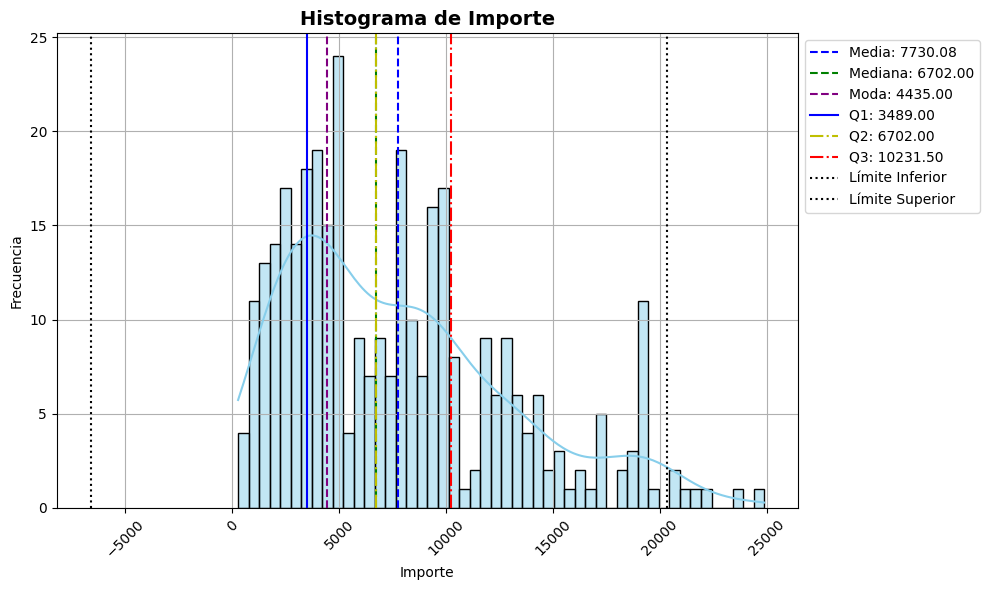

Insight:
El negocio tiene una gran cantidad de transacciones pequeñas, pero unas pocas ventas de alto valor impulsan los ingresos.
Esto muestra una distribución sesgada a la derecha (asimetría positiva).
Oportunidad: aumentar el valor del ticket promedio para mover más clientes hacia la 'cola' del histograma.



/var/folders/py/337h4wz56hv29t1tbtztkpp80000gq/T/ipykernel_61339/73003244.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gasto_segmentado, x='tipo_cliente', y='importe', palette='Set2')


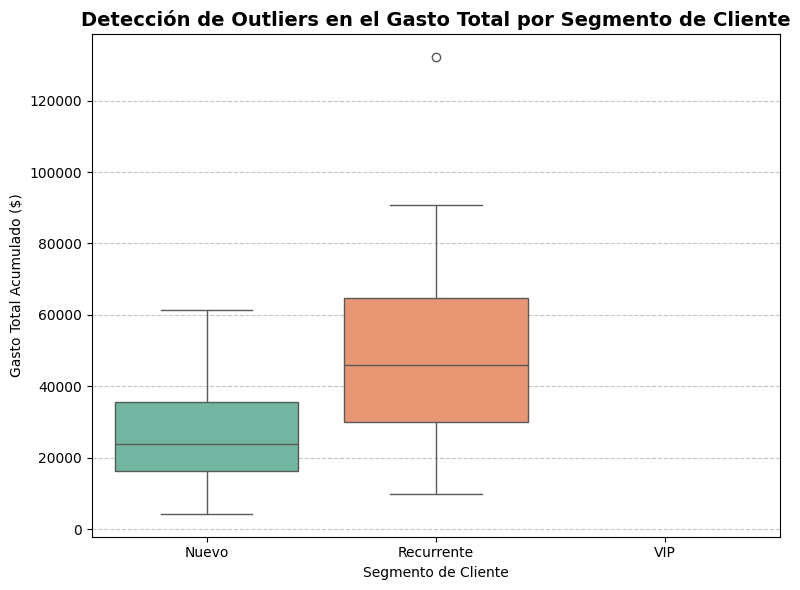

Insight:
Los clientes VIP son un subgrupo de los más leales. No solo detectamos outliers, sino que entendemos quiénes son.
Oportunidad: diseñar un programa de retención y fidelización específico para este grupo de alto valor.



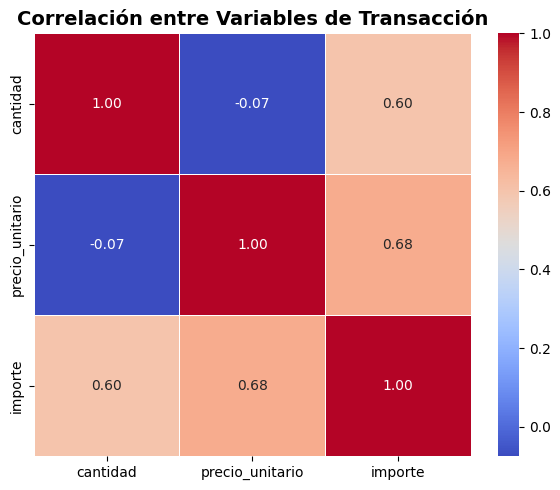

Insight:
Existen dos palancas para aumentar ingresos: vender más unidades o incentivar compras de mayor valor.
Oportunidad: aplicar estrategias combinadas de 'bundle' y 'upselling' para potenciar ambas.



In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n============================================")
print("VISUALIZACIÓN Y ANÁLISIS GRÁFICO")
print("============================================\n")

# ============================================
# 1️⃣ HISTOGRAMA: Distribución del Importe por Línea de Venta
# ============================================

plt.figure(figsize=(10, 6))

# Histograma con KDE
sns.histplot(importe_ventas_detalle, bins=50, kde=True, color='skyblue', edgecolor='black')

# Líneas verticales usando tus cálculos
plt.axvline(media_importe_vd, color='blue', linestyle='--', label=f'Media: {media_importe_vd:.2f}')
plt.axvline(mediana_importe_vd, color='green', linestyle='--', label=f'Mediana: {mediana_importe_vd:.2f}')
# Moda: puede haber varias, usamos la primera
plt.axvline(moda_importe_vd[0], color='purple', linestyle='--', label=f'Moda: {moda_importe_vd[0]:.2f}')

# Cuartiles
plt.axvline(q1_importe_vd, color='b', linestyle='-', label=f'Q1: {q1_importe_vd:.2f}')
plt.axvline(mediana_importe_vd, color='y', linestyle='-.', label=f'Q2: {mediana_importe_vd:.2f}')
plt.axvline(q3_importe_vd, color='r', linestyle='-.', label=f'Q3: {q3_importe_vd:.2f}')

# Límites de outliers
plt.axvline(lim_inferior_importe_vd, color='black', linestyle=':', label='Límite Inferior')
plt.axvline(lim_superior_importe_vd, color='black', linestyle=':', label='Límite Superior')

plt.title('Histograma de Importe', fontsize=14, fontweight='bold')
plt.xlabel('Importe')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print("Insight:")
print("El negocio tiene una gran cantidad de transacciones pequeñas, pero unas pocas ventas de alto valor impulsan los ingresos.")
print("Esto muestra una distribución sesgada a la derecha (asimetría positiva).")
print("Oportunidad: aumentar el valor del ticket promedio para mover más clientes hacia la 'cola' del histograma.\n")

# ============================================
# 2️⃣ BOXPLOT: Detección de Outliers por Segmento de Cliente
# ============================================

# 🔹 Primero preparamos los datos: Gasto total por cliente y su tipo
# Unimos clientes con su gasto total (ya calculado como gasto_por_cliente)

# Contamos la cantidad de compras por cliente
compras_por_cliente = ventas_df_norm.groupby('id_cliente').size()

# Creamos la columna tipo_cliente
tipo_cliente = pd.cut(
    compras_por_cliente,
    bins=[0, 1, 5, compras_por_cliente.max() + 1], # +1 para incluir el máximo
    labels=['Nuevo', 'Recurrente', 'VIP']
)

# Lo transformamos en DataFrame
segmentos_clientes = pd.DataFrame({
    'id_cliente': compras_por_cliente.index,
    'tipo_cliente': tipo_cliente.values
})

gasto_segmentado = gasto_por_cliente.reset_index().merge(segmentos_clientes, on='id_cliente', how='left')


plt.figure(figsize=(8, 6))
sns.boxplot(data=gasto_segmentado, x='tipo_cliente', y='importe', palette='Set2')
plt.title("Detección de Outliers en el Gasto Total por Segmento de Cliente", fontsize=14, fontweight='bold')
plt.xlabel("Segmento de Cliente")
plt.ylabel("Gasto Total Acumulado ($)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Insight:")
print("Los clientes VIP son un subgrupo de los más leales. No solo detectamos outliers, sino que entendemos quiénes son.")
print("Oportunidad: diseñar un programa de retención y fidelización específico para este grupo de alto valor.\n")

# ============================================
# 3️⃣ HEATMAP: Correlación entre variables de transacción
# ============================================

# 🔹 Creamos un DataFrame con las tres variables principales
corr_df = ventas_detalle_df_norm[['cantidad', 'precio_unitario', 'importe']]

# Calculamos la matriz de correlación
corr_matrix = corr_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlación entre Variables de Transacción", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight:")
print("Existen dos palancas para aumentar ingresos: vender más unidades o incentivar compras de mayor valor.")
print("Oportunidad: aplicar estrategias combinadas de 'bundle' y 'upselling' para potenciar ambas.\n")


## Creacion de una unica tabla para realizar analisis

### Primero veo las tablas para corroborar la normalizacion

In [72]:
clientes_df_norm.head()

,id_cliente,cliente,email,ciudad,alta
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,01-01-2023
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,02-01-2023
2,3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,03-01-2023
3,4,Uma Martinez,uma.martinez@mail.com,Carlos Paz,04-01-2023
4,5,Agustina Flores,agustina.flores@mail.com,Cordoba,05-01-2023


In [73]:
productos_df_norm.head()

,id_producto,producto,categoria,precio
0,1,Coca Cola 1.5L,Alimentos,2347.0
1,2,Pepsi 1.5L,Limpieza,4973.0
2,3,Sprite 1.5L,Alimentos,4964.0
3,4,Fanta Naranja 1.5L,Limpieza,2033.0
4,5,Agua Mineral 500ml,Alimentos,4777.0


In [74]:
ventas_df_encoded.head()

,id_venta,fecha,id_cliente,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia
0,1,19-06-2024,62,False,False,True,False
1,2,17-03-2024,49,False,True,False,False
2,3,13-01-2024,20,False,False,True,False
3,4,27-02-2024,36,False,False,False,True
4,5,11-06-2024,56,False,False,True,False


In [75]:
ventas_detalle_df_norm.head()

,id_venta,id_producto,cantidad,precio_unitario,importe,importe_std
0,1,90,1,2902.0,2902.0,-0.918259
1,2,82,5,2394.0,11970.0,0.806396
2,2,39,5,469.0,2345.0,-1.024196
3,2,70,2,4061.0,8122.0,0.074540
4,2,22,1,2069.0,2069.0,-1.076688


### Ahora concatenamos todas las tablas para generar un csv con el que vamos a trabajar

In [82]:
# Paso 1: Renombrar los IDs para evitar confusión
clientes_df_norm = clientes_df_norm.rename(columns={'id': 'id_cliente'})
productos_df_norm = productos_df_norm.rename(columns={'id': 'id_producto'})
ventas_df_encoded = ventas_df_encoded.rename(columns={'id': 'id_venta'})
ventas_detalle_df_norm = ventas_detalle_df_norm.rename(
    columns={'ID_venta': 'id_venta', 'FK_producto': 'id_producto'}
)

# Paso 2: Unimos el detalle con la venta
detalle_ventas_full = pd.merge(
    ventas_detalle_df_norm,
    ventas_df_encoded,
    on='id_venta',
    how='left'
)

# Paso 3: Agregamos la info del cliente
detalle_ventas_full = pd.merge(
    detalle_ventas_full,
    clientes_df_norm,
    on='id_cliente',
    how='left'
)

# Paso 4: Agregamos la info del producto
detalle_ventas_full = pd.merge(
    detalle_ventas_full,
    productos_df_norm,
    on='id_producto',
    how='left'
)

# Paso 5: Reordenamos las columnas para mayor claridad, incluyendo los IDs
columnas_ordenadas = [
    'id_venta', 'fecha',
    'id_cliente', 'cliente', 'email', 'ciudad', 'alta',
    'id_producto', 'producto', 'categoria',
    'cantidad', 'precio_unitario', 'importe', 'importe_std',
    'medio_pago_efectivo', 'medio_pago_qr', 'medio_pago_tarjeta', 'medio_pago_transferencia',
    'precio'
]

# Tomamos solo las columnas que existan (por si alguna falta)
columnas_finales = [col for col in columnas_ordenadas if col in detalle_ventas_full.columns]
ventas_master_df = detalle_ventas_full[columnas_finales]

# Paso 6: Guardamos en CSV
ventas_master_df.to_csv("ventas_master.csv", index=False, encoding='utf-8-sig')

print("Archivo 'ventas_master.csv' creado con éxito")
print("Filas totales:", len(ventas_master_df))
ventas_master_df.head()


Archivo 'ventas_master.csv' creado con éxito
Filas totales: 343


,id_venta,fecha,id_cliente,cliente,email,ciudad,alta,id_producto,producto,categoria,cantidad,precio_unitario,importe,importe_std,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia,precio
0,1,19-06-2024,62,Guadalupe Romero,guadalupe.romero@mail.com,Carlos Paz,03-03-2023,90,Toallas Húmedas x50,Limpieza,1,2902.0,2902.0,-0.918259,False,False,True,False,2902.0
1,2,17-03-2024,49,Olivia Gomez,olivia.gomez@mail.com,Rio Cuarto,18-02-2023,82,Aceitunas Negras 200g,Limpieza,5,2394.0,11970.0,0.806396,False,True,False,False,2394.0
2,2,17-03-2024,49,Olivia Gomez,olivia.gomez@mail.com,Rio Cuarto,18-02-2023,39,Helado Vainilla 1L,Alimentos,5,469.0,2345.0,-1.024196,False,True,False,False,469.0
3,2,17-03-2024,49,Olivia Gomez,olivia.gomez@mail.com,Rio Cuarto,18-02-2023,70,Fernet 750ml,Limpieza,2,4061.0,8122.0,0.074540,False,True,False,False,4061.0
4,2,17-03-2024,49,Olivia Gomez,olivia.gomez@mail.com,Rio Cuarto,18-02-2023,22,Medialunas de Manteca,Limpieza,1,2069.0,2069.0,-1.076688,False,True,False,False,2069.0


### Unificacion de tablas para analisis avanzado

In [85]:
# Elimin0 la columna duplicada 'precio'
if 'precio' in ventas_master_df.columns:
    ventas_master_df = ventas_master_df.drop(columns=['precio'])

# Renombro los IDs según su rol
ventas_master_df = ventas_master_df.rename(columns={
    'id_venta': 'PK_id_venta',
    'id_cliente': 'FK_id_cliente',
    'id_producto': 'FK_id_producto'
})

# Reordeno las columnas para mayor consistencia
columnas_ordenadas = [
    # Información de la venta
    'PK_id_venta', 'fecha',

    # Información del cliente
    'FK_id_cliente', 'cliente', 'email', 'ciudad', 'alta',

    # Información del producto
    'FK_id_producto', 'producto', 'categoria',

    # Detalle de la transacción
    'cantidad', 'precio_unitario', 'importe', 'importe_std',

    # Medios de pago
    'medio_pago_efectivo', 'medio_pago_qr',
    'medio_pago_tarjeta', 'medio_pago_transferencia'
]

# Validamos que las columnas existan antes de seleccionar
columnas_finales = [col for col in columnas_ordenadas if col in ventas_master_df.columns]
ventas_master_df = ventas_master_df[columnas_finales]

# verificamos resultado de la unificacion
print("Tabla master actualizada con convenciones de PK y FK.")
print(f"Columnas finales ({len(ventas_master_df.columns)}): {list(ventas_master_df.columns)}")
ventas_master_df.head()

Tabla master actualizada con convenciones de PK y FK.
Columnas finales (18): ['PK_id_venta', 'fecha', 'FK_id_cliente', 'cliente', 'email', 'ciudad', 'alta', 'FK_id_producto', 'producto', 'categoria', 'cantidad', 'precio_unitario', 'importe', 'importe_std', 'medio_pago_efectivo', 'medio_pago_qr', 'medio_pago_tarjeta', 'medio_pago_transferencia']


,PK_id_venta,fecha,FK_id_cliente,cliente,email,ciudad,alta,FK_id_producto,producto,categoria,cantidad,precio_unitario,importe,importe_std,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia
0,1,19-06-2024,62,Guadalupe Romero,guadalupe.romero@mail.com,Carlos Paz,03-03-2023,90,Toallas Húmedas x50,Limpieza,1,2902.0,2902.0,-0.918259,False,False,True,False
1,2,17-03-2024,49,Olivia Gomez,olivia.gomez@mail.com,Rio Cuarto,18-02-2023,82,Aceitunas Negras 200g,Limpieza,5,2394.0,11970.0,0.806396,False,True,False,False
2,2,17-03-2024,49,Olivia Gomez,olivia.gomez@mail.com,Rio Cuarto,18-02-2023,39,Helado Vainilla 1L,Alimentos,5,469.0,2345.0,-1.024196,False,True,False,False
3,2,17-03-2024,49,Olivia Gomez,olivia.gomez@mail.com,Rio Cuarto,18-02-2023,70,Fernet 750ml,Limpieza,2,4061.0,8122.0,0.074540,False,True,False,False
4,2,17-03-2024,49,Olivia Gomez,olivia.gomez@mail.com,Rio Cuarto,18-02-2023,22,Medialunas de Manteca,Limpieza,1,2069.0,2069.0,-1.076688,False,True,False,False


### Creacion analisis avanzado

#### Importe total

In [90]:
monto_total_facturado = ventas_master_df['importe'].sum()
print("MONTO TOTAL FACTURADO:")
print(f"${monto_total_facturado:,.2f}")

MONTO TOTAL FACTURADO:
$2,651,417.00


#### Clientes que mas compraron

In [86]:
print("============================================")
print("ANÁLISIS DE CLIENTES QUE MÁS COMPRARON")
print("============================================\n")

# Total de compras por cliente (cantidad de ventas distintas)
compras_por_cliente = (
    ventas_master_df.groupby(['FK_id_cliente', 'cliente'])['PK_id_venta']
    .nunique()
    .sort_values(ascending=False)
)

# Total de productos comprados (sumatoria de cantidad)
productos_por_cliente = (
    ventas_master_df.groupby(['FK_id_cliente', 'cliente'])['cantidad']
    .sum()
    .sort_values(ascending=False)
)

# Total gastado por cliente (sumatoria de importe)
gasto_por_cliente = (
    ventas_master_df.groupby(['FK_id_cliente', 'cliente'])['importe']
    .sum()
    .sort_values(ascending=False)
)

print("TOP 5 CLIENTES POR CANTIDAD DE COMPRAS:")
print(compras_por_cliente.head(5))
print("\nTOP 5 CLIENTES POR CANTIDAD DE PRODUCTOS:")
print(productos_por_cliente.head(5))
print("\nTOP 5 CLIENTES POR GASTO TOTAL ($):")
print(gasto_por_cliente.head(5))

ANÁLISIS DE CLIENTES QUE MÁS COMPRARON

TOP 5 CLIENTES POR CANTIDAD DE COMPRAS:
FK_id_cliente  cliente         
56             Bruno Diaz          5
5              Agustina Flores     4
42             Tomas Flores        4
49             Olivia Gomez        4
72             Camila Rodriguez    4
Name: PK_id_venta, dtype: int64

TOP 5 CLIENTES POR CANTIDAD DE PRODUCTOS:
FK_id_cliente  cliente        
5              Agustina Flores    50
49             Olivia Gomez       32
56             Bruno Diaz         31
25             Karina Castro      30
52             Diego Diaz         29
Name: cantidad, dtype: int64

TOP 5 CLIENTES POR GASTO TOTAL ($):
FK_id_cliente  cliente        
5              Agustina Flores    132158.0
56             Bruno Diaz          90701.0
52             Diego Diaz          90522.0
25             Karina Castro       81830.0
1              Mariana Lopez       72448.0
Name: importe, dtype: float64


#### Clientes recurrentes vs Nuevos

In [87]:
print("\n============================================")
print("CLIENTES RECURRENTES VS NUEVOS")
print("============================================\n")

clientes_recurrentes = compras_por_cliente[compras_por_cliente > 1].count()
clientes_unicos = compras_por_cliente.count()
clientes_nuevos = clientes_unicos - clientes_recurrentes

porc_recurrentes = round((clientes_recurrentes / clientes_unicos) * 100, 2)
porc_nuevos = round((clientes_nuevos / clientes_unicos) * 100, 2)

print(f"Clientes únicos totales: {clientes_unicos}")
print(f"Clientes que compraron más de una vez: {clientes_recurrentes} ({porc_recurrentes}%)")
print(f"Clientes que compraron una sola vez: {clientes_nuevos} ({porc_nuevos}%)")


CLIENTES RECURRENTES VS NUEVOS

Clientes únicos totales: 67
Clientes que compraron más de una vez: 37 (55.22%)
Clientes que compraron una sola vez: 30 (44.78%)


#### Productos mas vendidos

In [88]:
print("\n============================================")
print("PRODUCTOS MÁS VENDIDOS")
print("============================================\n")

# Por cantidad
productos_mas_vendidos = (
    ventas_master_df.groupby(['FK_id_producto', 'producto'])['cantidad']
    .sum()
    .sort_values(ascending=False)
)

# Por facturación
productos_mayor_facturacion = (
    ventas_master_df.groupby(['FK_id_producto', 'producto'])['importe']
    .sum()
    .sort_values(ascending=False)
)

print("TOP 5 PRODUCTOS MÁS VENDIDOS (POR CANTIDAD):")
print(productos_mas_vendidos.head(5))
print("\nTOP 5 PRODUCTOS CON MAYOR FACTURACIÓN (POR IMPORTE):")
print(productos_mayor_facturacion.head(5))



PRODUCTOS MÁS VENDIDOS

TOP 5 PRODUCTOS MÁS VENDIDOS (POR CANTIDAD):
FK_id_producto  producto                  
43              Salsa de Tomate 500g          27
18              Queso Rallado 150g            26
79              Hamburguesas Congeladas x4    24
68              Vino Blanco 750ml             22
81              Aceitunas Verdes 200g         22
Name: cantidad, dtype: int64

TOP 5 PRODUCTOS CON MAYOR FACTURACIÓN (POR IMPORTE):
FK_id_producto  producto                  
91              Desodorante Aerosol           93800.0
18              Queso Rallado 150g            89544.0
76              Pizza Congelada Muzzarella    85720.0
72              Ron 700ml                     81396.0
9               Yerba Mate Suave 1kg          77560.0
Name: importe, dtype: float64


#### Fecha mayor venta

In [89]:
print("\n============================================")
print("FECHA DE MAYOR VENTA")
print("============================================\n")

# Agrupamos por fecha sumando el importe total
ventas_por_fecha = (
    ventas_master_df.groupby('fecha')['importe']
    .sum()
    .sort_values(ascending=False)
)

fecha_top = ventas_por_fecha.idxmax()
monto_top = ventas_por_fecha.max()

print(f"Fecha de mayor venta: {fecha_top}")
print(f"Total facturado ese día: ${monto_top:,.2f}")



FECHA DE MAYOR VENTA

Fecha de mayor venta: 10-01-2024
Total facturado ese día: $84,236.00


In [79]:
print("============================================")
print("ANÁLISIS AVANZADO DE CLIENTES Y PRODUCTOS (TABLA MASTER)")
print("============================================\n")

# ============================================
# CLIENTES QUE MÁS COMPRARON
# ============================================

# Total de compras por cliente (cantidad de registros por cliente)
compras_por_cliente = ventas_master_df.groupby('cliente').size().sort_values(ascending=False)

# Total gastado por cliente
gasto_por_cliente = (
    ventas_master_df.groupby('cliente')['importe']
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 5 CLIENTES POR CANTIDAD DE COMPRAS:")
print(compras_por_cliente.head(5))

print("\nTOP 5 CLIENTES POR GASTO TOTAL ($):")
print(gasto_por_cliente.head(5))

# ============================================
# CLIENTES RECURRENTES VS NUEVOS
# ============================================

clientes_recurrentes = compras_por_cliente[compras_por_cliente > 1].count()
clientes_unicos = compras_por_cliente.count()
clientes_nuevos = clientes_unicos - clientes_recurrentes

porc_recurrentes = round((clientes_recurrentes / clientes_unicos) * 100, 2)
porc_nuevos = round((clientes_nuevos / clientes_unicos) * 100, 2)

print("\nCLIENTES RECURRENTES VS NUEVOS:")
print(f"Clientes únicos totales: {clientes_unicos}")
print(f"Clientes que compraron más de una vez: {clientes_recurrentes} ({porc_recurrentes}%)")
print(f"Clientes que compraron una sola vez: {clientes_nuevos} ({porc_nuevos}%)")

# ============================================
# PRODUCTO MÁS VENDIDO
# ============================================

# Por cantidad total de unidades
productos_mas_vendidos = (
    ventas_master_df.groupby('producto')['cantidad']
    .sum()
    .sort_values(ascending=False)
)

# Por ingresos totales
productos_mayor_facturacion = (
    ventas_master_df.groupby('producto')['importe']
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 5 PRODUCTOS MÁS VENDIDOS (POR CANTIDAD):")
print(productos_mas_vendidos.head(5))

print("\nTOP 5 PRODUCTOS CON MAYOR FACTURACIÓN (POR IMPORTE):")
print(productos_mayor_facturacion.head(5))

# ============================================
# FECHA DE MAYOR VENTA
# ============================================

# Convertimos la fecha a formato datetime por si aún es texto
ventas_master_df['fecha'] = pd.to_datetime(ventas_master_df['fecha'], format='%d-%m-%Y')

ventas_por_fecha = (
    ventas_master_df.groupby('fecha')['importe']
    .sum()
    .sort_values(ascending=False)
)

fecha_top = ventas_por_fecha.idxmax()
print(f"\n📅 Fecha de mayor venta: {fecha_top.date()} (Total: ${ventas_por_fecha.max():,.2f})")


ANÁLISIS AVANZADO DE CLIENTES Y PRODUCTOS (TABLA MASTER)


TOP 5 CLIENTES POR CANTIDAD DE COMPRAS:
cliente
Agustina Flores    15
Olivia Gomez       13
Diego Diaz         11
Bruno Castro       10
Bruno Diaz         10
dtype: int64

TOP 5 CLIENTES POR GASTO TOTAL ($):
cliente
Agustina Flores    132158.0
Bruno Castro       118790.0
Bruno Diaz          90701.0
Diego Diaz          90522.0
Karina Castro       81830.0
Name: importe, dtype: float64

CLIENTES RECURRENTES VS NUEVOS:
Clientes únicos totales: 64
Clientes que compraron más de una vez: 61 (95.31%)
Clientes que compraron una sola vez: 3 (4.69%)

TOP 5 PRODUCTOS MÁS VENDIDOS (POR CANTIDAD):
producto
Salsa de Tomate 500g          27
Queso Rallado 150g            26
Hamburguesas Congeladas x4    24
Vino Blanco 750ml             22
Aceitunas Verdes 200g         22
Name: cantidad, dtype: int64

TOP 5 PRODUCTOS CON MAYOR FACTURACIÓN (POR IMPORTE):
producto
Desodorante Aerosol           93800.0
Queso Rallado 150g            89544.0
Pizza Co

### Creacion de graficos


VISUALIZACIÓN Y ANÁLISIS GRÁFICO (TABLA MASTER)



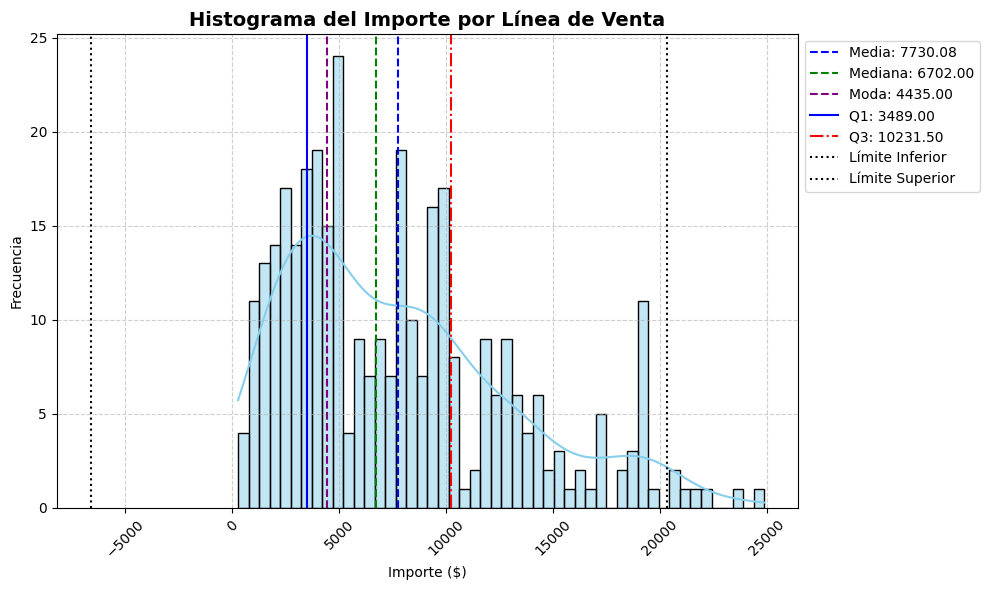

Insight:
El negocio tiene una gran cantidad de transacciones pequeñas, pero unas pocas ventas de alto valor impulsan los ingresos.
Esto muestra una distribución sesgada a la derecha (asimetría positiva).
Oportunidad: aumentar el valor del ticket promedio para mover más clientes hacia la 'cola' del histograma.



/var/folders/py/337h4wz56hv29t1tbtztkpp80000gq/T/ipykernel_61339/1487700577.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gasto_segmentado, x='tipo_cliente', y='importe', palette='Set2')


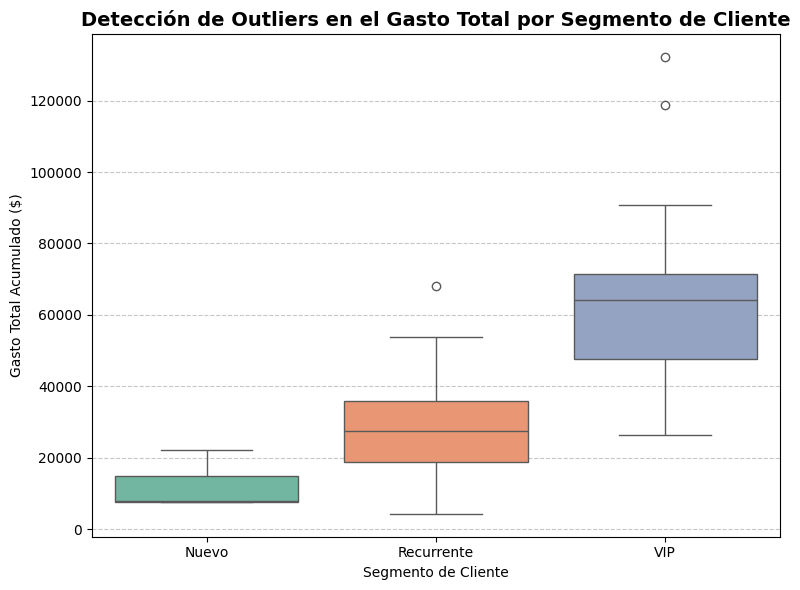

Insight:
Los clientes VIP son un subgrupo de los más leales. No solo detectamos outliers, sino que entendemos quiénes son.
Oportunidad: diseñar un programa de retención y fidelización específico para este grupo de alto valor.



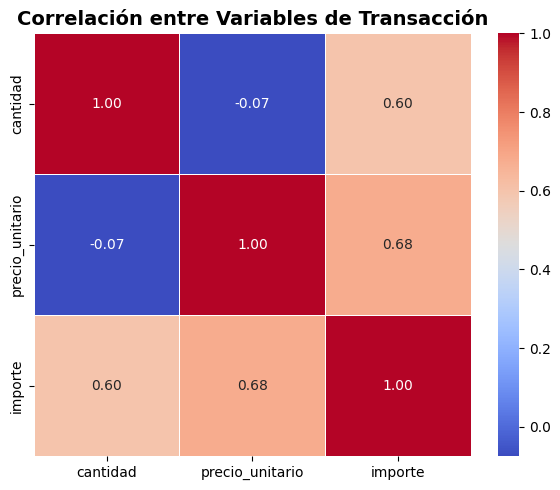

Insight:
Existen dos palancas para aumentar ingresos: vender más unidades o incentivar compras de mayor valor.
Oportunidad: aplicar estrategias combinadas de 'bundle' y 'upselling' para potenciar ambas.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("\n============================================")
print("VISUALIZACIÓN Y ANÁLISIS GRÁFICO (TABLA MASTER)")
print("============================================\n")

# ============================================
# 1️⃣ HISTOGRAMA: Distribución del Importe por Línea de Venta
# ============================================

# Creamos la variable directamente desde la tabla master
importe_ventas_detalle = ventas_master_df['importe']

# Cálculos estadísticos
media_importe_vd = importe_ventas_detalle.mean()
mediana_importe_vd = importe_ventas_detalle.median()
moda_importe_vd = importe_ventas_detalle.mode()
q1_importe_vd = importe_ventas_detalle.quantile(0.25)
q3_importe_vd = importe_ventas_detalle.quantile(0.75)
iqr = q3_importe_vd - q1_importe_vd
lim_inferior_importe_vd = q1_importe_vd - 1.5 * iqr
lim_superior_importe_vd = q3_importe_vd + 1.5 * iqr

# Histograma con KDE
plt.figure(figsize=(10, 6))
sns.histplot(importe_ventas_detalle, bins=50, kde=True, color='skyblue', edgecolor='black')

# Líneas de referencia
plt.axvline(media_importe_vd, color='blue', linestyle='--', label=f'Media: {media_importe_vd:.2f}')
plt.axvline(mediana_importe_vd, color='green', linestyle='--', label=f'Mediana: {mediana_importe_vd:.2f}')
plt.axvline(moda_importe_vd[0], color='purple', linestyle='--', label=f'Moda: {moda_importe_vd[0]:.2f}')
plt.axvline(q1_importe_vd, color='b', linestyle='-', label=f'Q1: {q1_importe_vd:.2f}')
plt.axvline(q3_importe_vd, color='r', linestyle='-.', label=f'Q3: {q3_importe_vd:.2f}')
plt.axvline(lim_inferior_importe_vd, color='black', linestyle=':', label='Límite Inferior')
plt.axvline(lim_superior_importe_vd, color='black', linestyle=':', label='Límite Superior')

plt.title('Histograma del Importe por Línea de Venta', fontsize=14, fontweight='bold')
plt.xlabel('Importe ($)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print("Insight:")
print("El negocio tiene una gran cantidad de transacciones pequeñas, pero unas pocas ventas de alto valor impulsan los ingresos.")
print("Esto muestra una distribución sesgada a la derecha (asimetría positiva).")
print("Oportunidad: aumentar el valor del ticket promedio para mover más clientes hacia la 'cola' del histograma.\n")

# ============================================
# 2️⃣ BOXPLOT: Detección de Outliers por Segmento de Cliente
# ============================================

# 🔹 Calculamos la cantidad de compras y gasto total por cliente
compras_por_cliente = ventas_master_df.groupby('cliente').size()
gasto_por_cliente = ventas_master_df.groupby('cliente')['importe'].sum()

# Creamos los segmentos
tipo_cliente = pd.cut(
    compras_por_cliente,
    bins=[0, 1, 5, compras_por_cliente.max() + 1],
    labels=['Nuevo', 'Recurrente', 'VIP']
)

# Construimos el DataFrame segmentado
gasto_segmentado = pd.DataFrame({
    'cliente': compras_por_cliente.index,
    'compras': compras_por_cliente.values,
    'importe': gasto_por_cliente.values,
    'tipo_cliente': tipo_cliente.values
})

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=gasto_segmentado, x='tipo_cliente', y='importe', palette='Set2')
plt.title("Detección de Outliers en el Gasto Total por Segmento de Cliente", fontsize=14, fontweight='bold')
plt.xlabel("Segmento de Cliente")
plt.ylabel("Gasto Total Acumulado ($)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Insight:")
print("Los clientes VIP son un subgrupo de los más leales. No solo detectamos outliers, sino que entendemos quiénes son.")
print("Oportunidad: diseñar un programa de retención y fidelización específico para este grupo de alto valor.\n")

# ============================================
# 3️⃣ HEATMAP: Correlación entre variables de transacción
# ============================================

# 🔹 Tomamos las columnas relevantes
corr_df = ventas_master_df[['cantidad', 'precio_unitario', 'importe']]

# Calculamos la matriz de correlación
corr_matrix = corr_df.corr()

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlación entre Variables de Transacción", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight:")
print("Existen dos palancas para aumentar ingresos: vender más unidades o incentivar compras de mayor valor.")
print("Oportunidad: aplicar estrategias combinadas de 'bundle' y 'upselling' para potenciar ambas.\n")

## Sugerencias COPILOT

### Primer Script


#### Limpieza Copilot

**Limpieza y transformaciones simples**

Esta sección aplica una limpieza básica y reproducible sobre las tablas de ventas y detalle de ventas: normaliza nombres, convierte fechas a datetime, completa valores faltantes con reglas sencillas, calcula importes cuando faltan y elimina duplicados y filas inválidas. Los comentarios en el código explican el porqué de cada paso.


**Limpieza simple y segura (comentarios incluidos)**
 1) Normalizar nombres de columnas (minúsculas y sin espacios)
 2) Convertir fechas a datetime (sin perder la columna original)
 3) Asegurar tipos numéricos y rellenar valores razonables
 4) Calcular importe si falta: cantidad * precio
 5) Quitar duplicados y filas con valores no válidos (precio<=0, cantidad<=0)

import pandas as pd
import numpy as np

**Copias para no modificar las originales**
```python
ventas = ventas_df_norm.copy() if 'ventas_df_norm' in globals() else (ventas_df.copy() if 'ventas_df' in globals() else None)
detalle = ventas_detalle_df_norm.copy() if 'ventas_detalle_df_norm' in globals() else (detalleVentas_df.copy() if 'detalleVentas_df' in globals() else None)
productos = productos_df_norm.copy() if 'productos_df_norm' in globals() else (productos_df.copy() if 'productos_df' in globals() else None)
clientes = clientes_df_norm.copy() if 'clientes_df_norm' in globals() else (clientes_df.copy() if 'clientes_df' in globals() else None)
```

**Validaciones básicas**
```python
if ventas is None or detalle is None:
    raise RuntimeError('No se encontraron las tablas necesarias (ventas y/o detalle). Ejecuta las celdas previas de carga.')
```

**--- Normalizar nombres de columnas ---**

```python
ventas.columns = [c.strip().lower() for c in ventas.columns]
detalle.columns = [c.strip().lower() for c in detalle.columns]
if productos is not None:
    productos.columns = [c.strip().lower() for c in productos.columns]
if clientes is not None:
    clientes.columns = [c.strip().lower() for c in clientes.columns]
```

**--- Fechas: crear columnas datetime sin eliminar las originales ---**
```python
# Ventas: puede existir 'fecha' en formato string; creamos 'fecha_dt'
if 'fecha' in ventas.columns:
    ventas['fecha_dt'] = pd.to_datetime(ventas['fecha'], dayfirst=True, errors='coerce')
```

**Clientes: convertir 'alta' si existe**
```python
if clientes is not None and 'alta' in clientes.columns:
    clientes['alta_dt'] = pd.to_datetime(clientes['alta'], dayfirst=True, errors='coerce')
```

**--- Tipos numéricos en detalle ---**
```python
# Columnas esperadas: id (o id_venta), id_producto, id_cliente, cantidad, precio, importe
for col in ['cantidad','precio','importe']:
    if col in detalle.columns:
        detalle[col] = pd.to_numeric(detalle[col], errors='coerce')
```

**Rellenos sencillos: cantidad -> 1 si falta**
```python
if 'cantidad' in detalle.columns:
    detalle['cantidad'] = detalle['cantidad'].fillna(1).astype(int)
```

**Si falta precio en el detalle, intentar traerlo desde la tabla de productos**
```python
if 'precio' not in detalle.columns or detalle['precio'].isnull().any():
    if productos is not None and 'id' in productos.columns:
        # aseguramos que productos tenga 'id' e 'precio'
        prod_map = productos.set_index('id')['precio'].to_dict() if 'precio' in productos.columns else {}
        # rellenar precio donde falte
        if 'precio' in detalle.columns:
            detalle['precio'] = detalle.apply(lambda r: prod_map.get(r.get('id_producto')) if pd.isna(r['precio']) else r['precio'], axis=1)
        else:
            # crear columna precio desde productos
            detalle['precio'] = detalle['id_producto'].map(prod_map)
```

**Calcular importe si está vacío o inconsistente**
```python
if 'importe' not in detalle.columns:
    detalle['importe'] = detalle['cantidad'] * detalle['precio']
else:
    # rellenar importe faltante
    detalle['importe'] = detalle.apply(lambda r: r['cantidad'] * r['precio'] if pd.isna(r['importe']) else r['importe'], axis=1)
```

**--- Eliminar duplicados simples ---**
```python
before = len(detalle)
detalle = detalle.drop_duplicates()
after = len(detalle)
```

**--- Eliminar filas inválidas ---**
```python
# precio y importe deben ser > 0, cantidad > 0
mask_valid = (~detalle['precio'].isna()) & (~detalle['importe'].isna()) & (detalle['precio'] > 0) & (detalle['importe'] >= 0) & (detalle['cantidad'] > 0)
detalle = detalle[mask_valid].reset_index(drop=True)
```

**--- Resumen y salida ---**
```python
print(f'Filas antes deduplicar: {before}, después deduplicar: {after}, después limpieza: {len(detalle)}')
print('\nValores nulos por columna (detalle):')
print(detalle.isna().sum())
print('\nTipos (detalle):')
print(detalle.dtypes)
```

**Guardamos la versión limpia en una variable accesible**
```python
df_clean = detalle.copy()
```

**Mostrar primeros registros limpios**
```python
print('\nPrimeros registros de df_clean:')
df_clean.head()
```


### Segundo Script


#### Analisis Copilot

**Por qué**
En esta sección aplico mejoras destinadas a dejar el dataset preparado para modelos de Machine Learning y análisis temporal reproducible. Las acciones incluyen:
- Mantener columnas datetime para análisis temporal y generación de features.
- Enriquecer cada fila del detalle de ventas con información de producto, venta y cliente (merge) para tener todas las variables necesarias por observación.
- Crear features relevantes (total por línea, month, dayofweek) que suelen mejorar modelos predictivos.
- Detectar y marcar outliers, y aplicar transformaciones (log) para reducir sesgo en variables monetarias.
- Calcular RFM para caracterizar clientes (útil para segmentación o como feature para modelos).
- Preparar un esqueleto de pipeline (encoding + scalers) y visualizaciones básicas para validar distribuciones.

Cada celda de código contiene comentarios con el porqué de cada paso.

**Qué hago en cada paso (resumen)**

1) Normalizo/creo columnas datetime a partir de la tabla de ventas original.
2) Hago merges para enriquecer el detalle de ventas con producto, venta y cliente.
3) Creo variables: precio unitario claro, total por línea, fecha en formato datetime, month, dow, importe_log.
4) Detecto outliers por IQR y genero una columna booleana 'is_outlier'.
5) Calculo RFM por cliente (Recency, Frequency, Monetary).
6) Muestro visualizaciones y dejo un esqueleto de pipeline para ML (encoding + scaler).

**1) Preprocesamiento y merges**
**Por qué: tener una tabla fila-a-fila con contexto (producto, venta, cliente) facilita la ingeniería de features y entrenamiento.**
```python
import pandas as pd
import numpy as np
```

**Uso copias locales para no alterar los dataframes originales en el notebook**
```python
ventas_orig = ventas_df.copy() if 'ventas_df' in globals() else ventas_df_norm.copy()
productos = productos_df_norm.copy()
clientes = clientes_df_norm.copy()
detalle = ventas_detalle_df_norm.copy()
```

**1.a - Asegurar que la fecha de la tabla de ventas sea datetime (mantener la versión string si la necesitas para display aparte)**
**Usamos ventas_orig que es la tabla original cargada con las fechas en formato interpretable**
```python
if 'fecha' in ventas_orig.columns:
    ventas_orig['fecha_dt'] = pd.to_datetime(ventas_orig['fecha'], dayfirst=True, errors='coerce')
else:
    # si no existe, tratamos de convertir la columna 'fecha' en ventas_df_norm
    ventas_orig['fecha_dt'] = pd.to_datetime(ventas_orig.get('fecha', None), dayfirst=True, errors='coerce')
```

**1.b - Preparar columnas para merge evitando colisiones de nombres**
**Renombramos columnas de detalle para mayor claridad**
```python
detalle = detalle.rename(columns={'id': 'id_venta', 'precio': 'precio_det', 'importe': 'importe_det'})
```

**Renombramos columnas de productos para que la llave sea 'id_producto' y el precio del producto quede como 'precio_prod'**
```python
productos = productos.rename(columns={'id': 'id_producto', 'precio': 'precio_prod'})
```

**Renombramos clientes para que la llave sea 'id_cliente'**
```python
clientes = clientes.rename(columns={'id': 'id_cliente', 'alta': 'fecha_alta_str'})
```

**1.c - Merge: detalle <- productos**
**Resultado: cada fila del detalle tendrá información del producto (nombre, categoría, precio de catálogo)**
```python
df = detalle.merge(productos, on='id_producto', how='left')
```

**1.d - Merge: añadir datos de la venta (cliente, medio de pago, fecha)**
**En ventas_orig la llave de venta puede ser 'id_venta' o 'id' (dependiendo de las transformaciones previas), identificamos la columna**
```python
venta_key = 'id_venta' if 'id_venta' in ventas_orig.columns else ('id' if 'id' in ventas_orig.columns else None)
if venta_key is None:
    raise ValueError('No se encontró la columna de id de venta en ventas_df/ventas_df_norm')
```

**Nos quedamos solo con las columnas relevantes para el merge**
```python
cols_ventas_keep = [venta_key, 'id_cliente'] + (['fecha_dt'] if 'fecha_dt' in ventas_orig.columns else ['fecha']) + (['medio_pago'] if 'medio_pago' in ventas_orig.columns else [])
cols_ventas_keep = [c for c in cols_ventas_keep if c in ventas_orig.columns]
ventas_for_merge = ventas_orig[cols_ventas_keep]
```

**Alineamos el nombre de la llave en ventas_for_merge a 'id_venta' para que el merge sea directo**
```python
ventas_for_merge = ventas_for_merge.rename(columns={venta_key: 'id_venta'})
```

**Merge final con ventas**
```python
df = df.merge(ventas_for_merge, on='id_venta', how='left')
```

**1.e - Merge: añadir datos del cliente (nombre, fecha de alta)**
**Nos aseguramos que clientes tenga la llave 'id_cliente'**
```python
if 'id_cliente' not in clientes.columns:
    clientes = clientes.rename(columns={'id': 'id_cliente'})

cols_clientes_keep = [c for c in ['id_cliente', 'cliente', 'fecha_alta_str'] if c in clientes.columns]
clientes_for_merge = clientes[cols_clientes_keep]

df = df.merge(clientes_for_merge, on='id_cliente', how='left')
```

**1.f - Aseguramos que exista una columna datetime en el dataframe final**
```python
if 'fecha_dt' not in df.columns:
    # si la columna fue 'fecha' o similar, intentamos parsear
    if 'fecha' in df.columns:
        df['fecha_dt'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
    else:
        df['fecha_dt'] = pd.NaT

# Vista rápida
print('Filas resultantes:', len(df))
print('Columnas claves presentes:', [c for c in ['id_venta','id_producto','id_cliente','fecha_dt','precio_det','importe_det'] if c in df.columns])
```

**Guardamos la tabla enriquecida en una variable para usar en los siguientes pasos**
```python
df_eda = df.copy()

df_eda.head()
```

**2) Ingeniería de variables y transformaciones**
**Por qué: crear features que los modelos y análisis sacarán provecho. Agrego comentarios explicativos.**

**2.a - Total por línea (cantidad * precio unitario del detalle)**
**Usamos 'precio_det' que viene del detalle, si no existe usamos 'precio_prod'**
```python
if 'precio_det' in df_eda.columns:
    df_eda['total_linea'] = df_eda['cantidad'] * df_eda['precio_det']
elif 'precio_prod' in df_eda.columns:
    df_eda['total_linea'] = df_eda['cantidad'] * df_eda['precio_prod']
else:
    df_eda['total_linea'] = np.nan
```

**2.b - Extraer componentes temporales (útiles para modelos y para análisis)**
**month, year, dayofweek (0=Lunes)**
```python
df_eda['year'] = df_eda['fecha_dt'].dt.year
df_eda['month'] = df_eda['fecha_dt'].dt.month
df_eda['dayofweek'] = df_eda['fecha_dt'].dt.dayofweek
```

**2.c - Transformaciones para reducir sesgo en variables monetarias**
Log-transform del importe y del total por línea (evita problemas si hay valores muy dispersos)
```python
df_eda['importe_log'] = np.log1p(df_eda['importe_det'].astype(float))
df_eda['total_linea_log'] = np.log1p(df_eda['total_linea'].astype(float))
```

**2.d - Detección de outliers por IQR sobre la variable importe_det (marca booleana)**
```python
Q1 = df_eda['importe_det'].quantile(0.25)
Q3 = df_eda['importe_det'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_eda['is_outlier_importe'] = ((df_eda['importe_det'] < lower_bound) | (df_eda['importe_det'] > upper_bound))


# Resumen rápido
print('Total filas:', len(df_eda))
print('Outliers de importe detectados:', df_eda['is_outlier_importe'].sum())

df_eda[[ 'id_venta','id_producto','id_cliente','cantidad','precio_det','importe_det','total_linea','importe_log','is_outlier_importe']].head()
```

**3) RFM (Recency, Frequency, Monetary) por cliente**
**Por qué: RFM es un descriptor potente para caracterizar clientes y puede usarse como target/feature.**

**Definimos la fecha de referencia como el último día conocido en los datos + 1 día**
```python
snapshot_date = df_eda['fecha_dt'].max() + pd.Timedelta(days=1)

rfm = df_eda.groupby('id_cliente').agg({
    'fecha_dt': lambda x: (snapshot_date - x.max()).days,  # Recency en días
    'id_venta': 'nunique',  # Frequency: número de ventas distintas
    'total_linea': 'sum'    # Monetary: gasto total
}).reset_index()

rfm.columns = ['id_cliente', 'recency_days', 'frequency', 'monetary']
```

**Ejemplo de rangos (opcional): convertir monetary a log para robustez**
```python
rfm['monetary_log'] = np.log1p(rfm['monetary'])

print('RFM sample:')
rfm.head()

# Guardamos rfm para futuros usos
rfm_df = rfm.copy()
```

**4) Esqueleto de pipeline para ML y visualizaciones básicas**
**Por qué: dejar ejemplos de encoding y escalado que después se incorporan en un Pipeline de sklearn.**
```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
```

**Columnas ejemplo**
```python
numeric_features = ['cantidad','precio_det','importe_det','total_linea']
cat_features = ['categoria','medio_pago'] if 'categoria' in df_eda.columns else ['medio_pago']
```

**Preprocessor de ejemplo**
```python
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing'))
    # para encoding se puede agregar OneHotEncoder o TargetEncoder en el pipeline real
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, [c for c in numeric_features if c in df_eda.columns]),
        ('cat', categorical_transformer, [c for c in cat_features if c in df_eda.columns])
    ]
)

pipeline_example = Pipeline(steps=[('preprocessor', preprocessor)])

print('Pipeline preparado (ejemplo). Columnas numéricas usadas:', [c for c in numeric_features if c in df_eda.columns])
```

**Visualizaciones rápidas para validar distribuciones (usa seaborn/matplotlib ya importados en el notebook)**
```python
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df_eda['importe_det'].dropna(), bins=30)
plt.title('Distribución de importe (raw)')

plt.subplot(1,2,2)
sns.histplot(df_eda['importe_log'].dropna(), bins=30)
plt.title('Distribución de importe (log1p)')

plt.tight_layout()

# Top 10 productos por ventas totales
top_products = df_eda.groupby('producto')['total_linea'].sum().nlargest(10)
print('\nTop 10 productos por ventas totales:')
print(top_products)
```
